In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# high res plots
import matplotlib_inline.backend_inline as bi
bi.set_matplotlib_formats('svg')

# Import GPT-2 and BERT tokenizers and models

In [ ]:
from transformers import BertTokenizer, BertModel, GPT2Tokenizer, GPT2Model

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')

gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2 = GPT2Model.from_pretrained('gpt2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print(gpt2)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [ ]:
print(bert)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

# How long are the tokens

In [ ]:
print(f'BERT size: {bert_tokenizer.vocab_size} tokens')
print(f'GPT2 size: {gpt2_tokenizer.vocab_size} tokens')

BERT size: 30522 tokens
GPT2 size: 50257 tokens


In [ ]:
dir(gpt2_tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_bos_token',
 '_add_eos_token',
 '_add_tokens',
 '_auto_class',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_decode',
 '_encode_plus',
 '_eventual_warn_about_too_long_sequence',
 '_extra_special_tokens',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_merges',
 '_pad',
 '_pad_token_type_id',
 '_patch_mistral_regex',
 '_post_init',
 '_processor_class',
 '_save_pretrained',
 '_set_mode

In [ ]:
dir(bert_tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_bos_token',
 '_add_eos_token',
 '_add_tokens',
 '_auto_class',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_decode',
 '_encode_plus',
 '_eventual_warn_about_too_long_sequence',
 '_extra_special_tokens',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_pad',
 '_pad_token_type_id',
 '_patch_mistral_regex',
 '_post_init',
 '_processor_class',
 '_save_pretrained',
 '_set_model_specific_s

In [ ]:
token_lengths = np.zeros(gpt2_tokenizer.vocab_size, dtype=int)

for token, idx in gpt2_tokenizer.get_vocab().items():
    token_lengths[idx] = len(token)

gpt_unique_lengths, gpt_token_count = np.unique(token_lengths, return_counts=True)

In [ ]:
# GPT: get all individual lengths
token_lengths = np.zeros(bert_tokenizer.vocab_size, dtype = int)

for idx, word in enumerate(bert_tokenizer.get_vocab().keys()):
  token_lengths[idx] = len(word)

# unique values and counts for bar plot
bert_unique_lengths, bert_token_count = np.unique(token_lengths, return_counts = True)

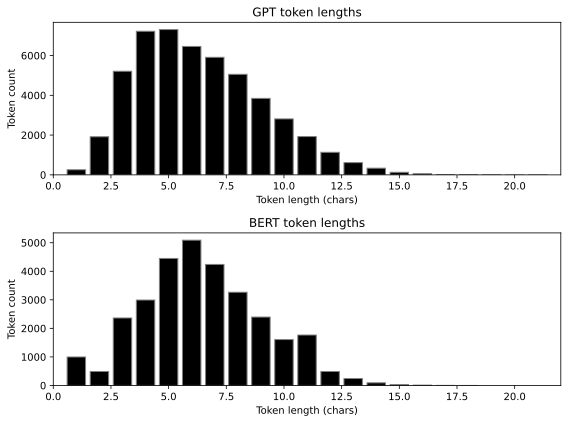

In [ ]:
# draw the barplot!
_, axs = plt.subplots(2,1,figsize=(8,6))
axs[0].bar(gpt_unique_lengths, gpt_token_count, color = 'k', edgecolor = 'gray')
axs[0].set(xlabel = 'Token length (chars)',
           ylabel = 'Token count',
           title = 'GPT token lengths',
           xlim = [0,22])

axs[1].bar(bert_unique_lengths, bert_token_count, color = 'k', edgecolor = 'gray')
axs[1].set(xlabel = 'Token length (chars)',
           ylabel = 'Token count',
           title = 'BERT token lengths',
           xlim = [0,22])
plt.tight_layout()
plt.show()

# Extract and visualize the embeddings

In [ ]:
gpt2_embeddings = gpt2.wte.weight.detach().numpy()
bert_embeddings = bert.embeddings.word_embeddings.weight.detach().numpy()

print(f'GPT2 embeddings matrix is of size: {gpt2_embeddings.shape}')
print(f'BERT embeddings matrix is of size: {bert_embeddings.shape}')

GPT2 embeddings matrix is of size: (50257, 768)
BERT embeddings matrix is of size: (30522, 768)


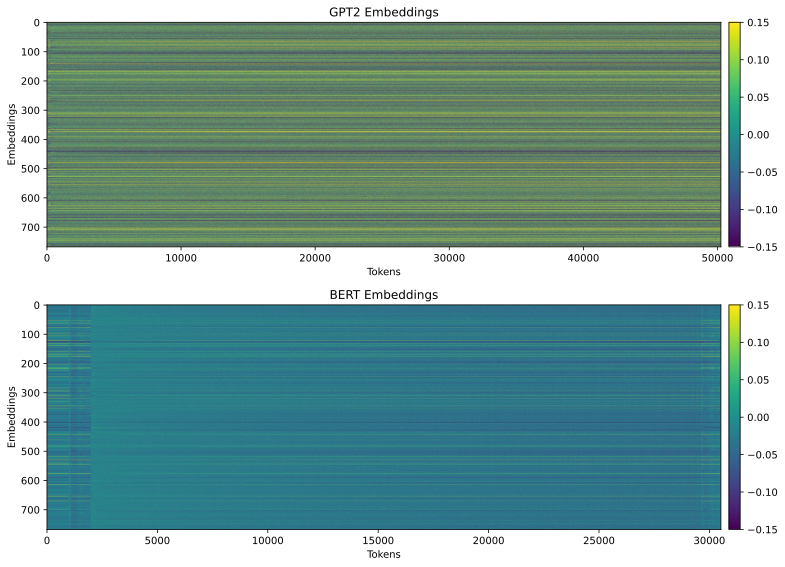

In [ ]:
fig, axs = plt.subplots(2, 1, figsize = (12, 8))

h = axs[0].imshow(gpt2_embeddings.T, aspect = 'auto', vmin = -.15, vmax = .15)
axs[0].set(xlabel = 'Tokens', ylabel = 'Embeddings', title = 'GPT2 Embeddings')
fig.colorbar(h, ax = axs[0], pad = 0.01)

h = axs[1].imshow(bert_embeddings.T, aspect = 'auto', vmin = -.15, vmax = .15)
axs[1].set(xlabel = 'Tokens', ylabel = 'Embeddings', title = 'BERT Embeddings')
fig.colorbar(h, ax = axs[1], pad = 0.01)

plt.tight_layout()
plt.show()

# Comparing the same token index

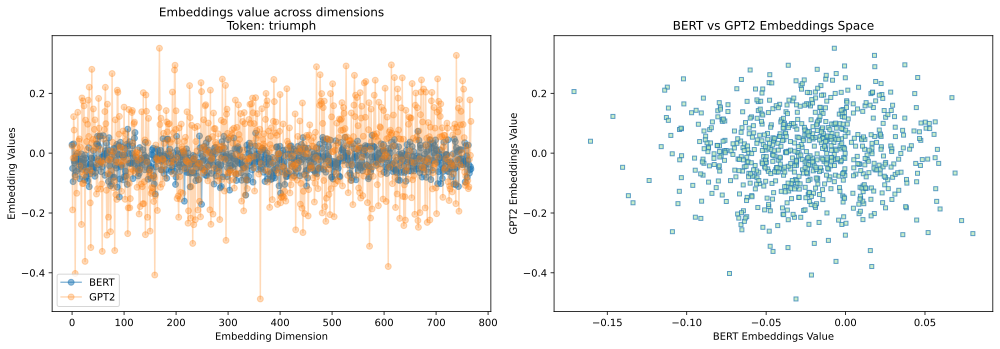

In [ ]:
rand_idx = np.random.randint(0, bert.embeddings.word_embeddings.weight.shape[0])
word     = bert_tokenizer.decode([rand_idx])

fig, axs = plt.subplots(1,2,figsize = (14,5))

axs[0].plot(bert_embeddings[rand_idx,:], '-o', alpha = .5, label = 'BERT')
axs[0].plot(gpt2_embeddings[rand_idx,:], '-o', alpha = .3, label = 'GPT2')
axs[0].set(xlabel = 'Embedding Dimension', ylabel = 'Embedding Values', title = f'Embeddings value across dimensions\nToken: {word}')
axs[0].legend()

axs[1].plot(bert_embeddings[rand_idx,:], gpt2_embeddings[rand_idx,:], 's', markerfacecolor=[0.7, 0.9, 0.7],markersize=4,alpha=0.7)
axs[1].set(xlabel = 'BERT Embeddings Value', ylabel = 'GPT2 Embeddings Value', title = 'BERT vs GPT2 Embeddings Space')

plt.tight_layout()
plt.show()

In [ ]:
token = ' the'
bert_token_idx = bert_tokenizer.encode(token)[1]
gpt2_token_idx = gpt2_tokenizer.encode(token)[0]

print(f'BERT: "{token}" in index {bert_token_idx}')
print(f'GPT2: "{token}" in index {gpt2_token_idx}')

BERT: " the" in index 1996
GPT2: " the" in index 262


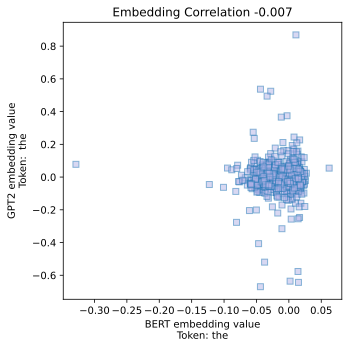

In [ ]:
corr = np.corrcoef(
    bert_embeddings[bert_token_idx,:],
    gpt2_embeddings[gpt2_token_idx,:]
)

corr_val = corr[0][1].item()

token_bert = bert_tokenizer.decode([bert_token_idx])
token_gpt2 = gpt2_tokenizer.decode([gpt2_token_idx])

plt.figure(figsize = (5,5))

plt.plot(bert_embeddings[bert_token_idx], gpt2_embeddings[gpt2_token_idx], 's', markerfacecolor = [.7,.7,.9], alpha = .5)

plt.title(f'Embedding Correlation {corr_val:.3f}')
plt.xlabel(f'BERT embedding value\nToken: {token_bert}')
plt.ylabel(f'GPT2 embedding value\nToken: {token_gpt2}')

plt.show()

# Distributions of embeddings characteristics

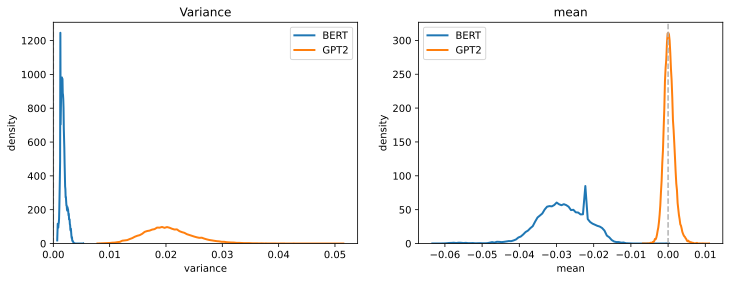

In [ ]:
fig, axs = plt.subplots(1,2,figsize = (12,4))

y_bert, x_bert = np.histogram(bert_embeddings.var(axis = 1), bins = 100, density = True)
y_gpt2, x_gpt2 = np.histogram(gpt2_embeddings.var(axis = 1), bins = 100, density = True)

axs[0].plot(x_bert[:-1], y_bert, linewidth = 2, label = "BERT")
axs[0].plot(x_gpt2[:-1], y_gpt2, linewidth = 2, label = 'GPT2')
axs[0].axvline(0, color = [.7,.7,.7], linestyle = '--')
axs[0].set(xlabel = 'variance', ylabel = 'density', xlim = [0, None], ylim = [0, None], title = 'Variance')
axs[0].legend()

y_bert, x_bert = np.histogram(bert_embeddings.mean(axis = 1), bins = 100, density = True)
y_gpt2, x_gpt2 = np.histogram(gpt2_embeddings.mean(axis = 1), bins = 100, density = True)

axs[1].plot(x_bert[:-1], y_bert, linewidth = 2, label = 'BERT')
axs[1].plot(x_gpt2[:-1], y_gpt2, linewidth = 2, label = 'GPT2')
axs[1].axvline(0, color = [.7,.7,.7], linestyle = '--')
axs[1].set(xlabel = 'mean', ylabel = 'density', ylim = [0,None], title = 'mean')
axs[1].legend()

plt.show()

* Variance
  * BERT has lower variance, meaning its representations are more concentrated in the embedding space. This suggests more stable and compact feature encoding, typically aligned with understanding-oriented tasks.
  * GPT-2 has higher variance, meaning its representations are more spread out in the embedding space. This indicates greater dispersion of activations, which may support more flexible generative behavior.

* Mean
  * BERT is slightly shifted to the left (mean < 0), indicating a small negative bias in its embedding distribution.
  * GPT-2 is centered almost exactly at 0 (mean ≈ 0), indicating a more symmetric embedding distribution around zero.


# Digit to Tokens

In [1]:
from transformers import GPT2Model, GPT2Tokenizer

gpt2 = GPT2Model.from_pretrained('gpt2')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [2]:
digits   = list(range(0, 10))
tens     = list(range(10, 101, 10))
hundreds = list(range(100, 1001, 100))

digits = digits + tens + hundreds

print(digits)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]


In [3]:
gpt2_tokenizer.encode(['1'])

[[16]]

In [4]:
digits_tokens = []
for d in digits:
  token = gpt2_tokenizer.encode(str(d))[0]
  digits_tokens.append(token)
  print(f'The number {d:>5} is token(s) {token}')

The number     0 is token(s) 15
The number     1 is token(s) 16
The number     2 is token(s) 17
The number     3 is token(s) 18
The number     4 is token(s) 19
The number     5 is token(s) 20
The number     6 is token(s) 21
The number     7 is token(s) 22
The number     8 is token(s) 23
The number     9 is token(s) 24
The number    10 is token(s) 940
The number    20 is token(s) 1238
The number    30 is token(s) 1270
The number    40 is token(s) 1821
The number    50 is token(s) 1120
The number    60 is token(s) 1899
The number    70 is token(s) 2154
The number    80 is token(s) 1795
The number    90 is token(s) 3829
The number   100 is token(s) 3064
The number   100 is token(s) 3064
The number   200 is token(s) 2167
The number   300 is token(s) 6200
The number   400 is token(s) 7029
The number   500 is token(s) 4059
The number   600 is token(s) 8054
The number   700 is token(s) 9879
The number   800 is token(s) 7410
The number   900 is token(s) 12865
The number  1000 is token(s) 12825

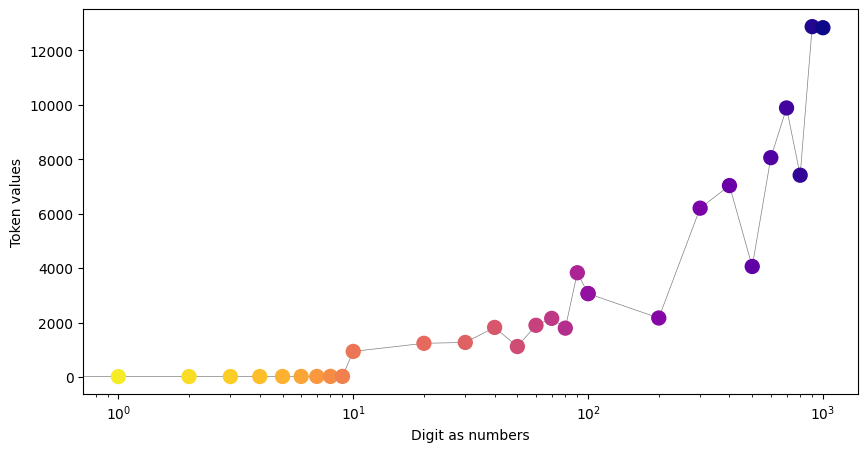

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (10, 5))
plt.plot(digits, digits_tokens, color = [.5,.5,.5], linewidth = .5)
plt.scatter(digits, digits_tokens, c = range(len(digits)), cmap = 'plasma_r', s = 100, marker = 'o', zorder = 10)
plt.gca().set(xlabel = 'Digit as numbers', ylabel = 'Token values', xticks = digits)
plt.gca().set(xscale = 'log')
plt.show()

## How long are numbers?

how many tokens are used to represent a number?

In [6]:
import numpy as np

# initialize
numnums       = 99_999
int_toklens   = np.zeros(numnums, dtype = int)
float_toklens = np.zeros(numnums, dtype = int)

# random numbers (std of 5)
ra = 5 * np.random.randn(numnums)

for i in range(numnums):
  # integers
  int_toklens[i] = len(gpt2_tokenizer.encode(str(i)))

  # and the random numbers
  float_toklens[i] = len(gpt2_tokenizer.encode(str(ra[i])))

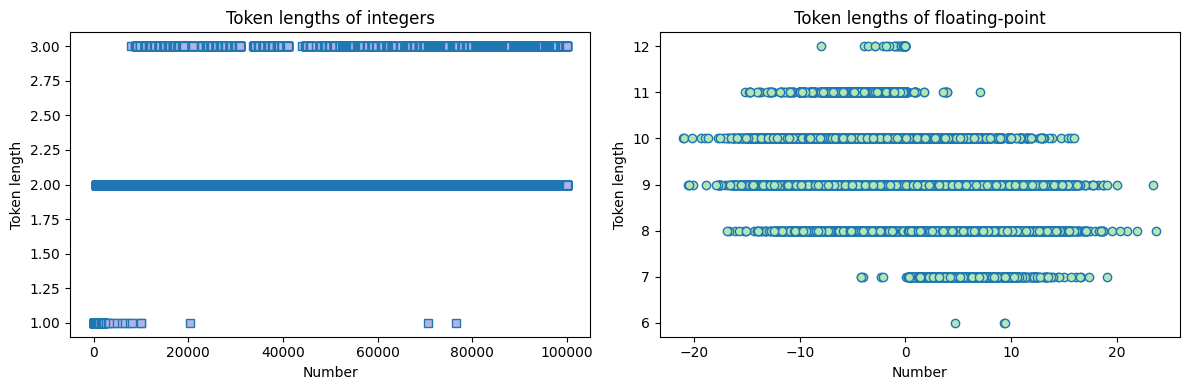

In [7]:
_, axs = plt.subplots(1, 2, figsize = (12, 4))

axs[0].plot(np.arange(numnums), int_toklens,   's', markerfacecolor = [.7,.7,.9])
axs[1].plot(ra,                 float_toklens, 'o', markerfacecolor = [.7,.9,.7])

axs[0].set(xlabel = 'Number', ylabel = 'Token length', title = 'Token lengths of integers')
axs[1].set(xlabel = 'Number', ylabel = 'Token length', title = 'Token lengths of floating-point')

plt.tight_layout()
plt.show()

## Does math work in token conversions?

In [8]:
# the equation and its tokens
eq     = '5 x 3 ='
tokens = gpt2_tokenizer.encode(eq)

# try the math
print(f'{eq} -> {tokens}')
print(f'Product of tokens = {np.prod(tokens)}')
# print(f'   which is "{gpt2_tokenizer.decode(np.prod(tokens))}"')

5 x 3 = -> [20, 2124, 513, 796]
Product of tokens = 17346623040


In [9]:
# maybe just the numbers?
t5 = gpt2_tokenizer.encode('5')
t3 = gpt2_tokenizer.encode('3')

# let's see...
print(f'"5" and "3" have tokens {t5} and {t3}.')
print(f'Their product is {t5[0]*t3[0]}, which is "{gpt2_tokenizer.decode(t5[0]*t3[0])}"')

"5" and "3" have tokens [20] and [18].
Their product is 360, which is " D"


## Does math work in embeddings conversions?

In [10]:
gpt2_embeddings = gpt2.wte.weight.detach().numpy()

In [11]:
gpt2_embeddings.shape

(50257, 768)

In [12]:
five             = str(5)
three            = str(3)
three_plus_five  = str(3+5)
three_times_five = str(3*5)

In [13]:
def embedding(s):
  return gpt2_embeddings[gpt2_tokenizer.encode(s)[0]]

In [14]:
five_em             = embedding(five)
three_em            = embedding(three)
three_plus_five_em  = five_em + three_em
three_times_five_em = five_em * three_em

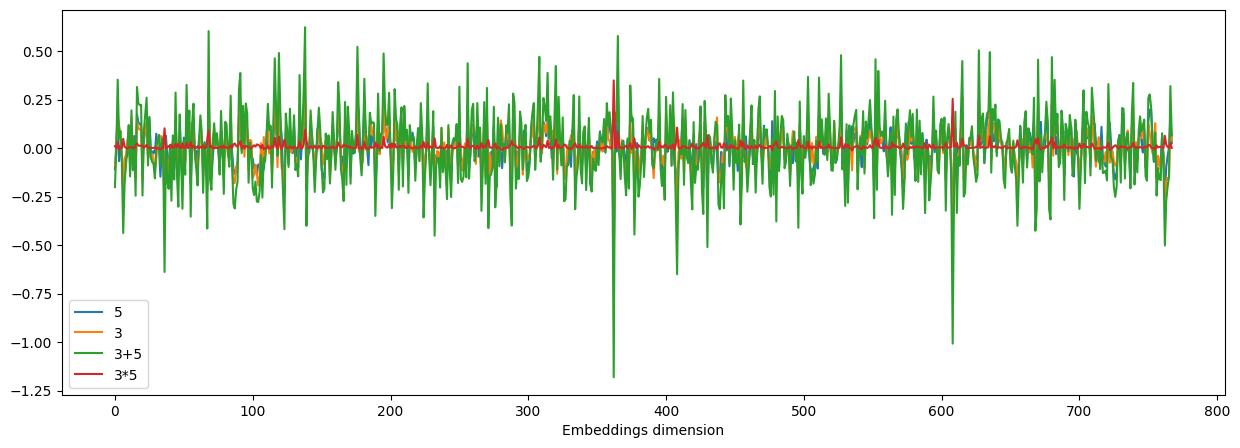

In [15]:
fig = plt.figure(figsize = (15, 5))

plt.plot(five_em, label = '5')
plt.plot(three_em, label = '3')
plt.plot(three_plus_five_em, label = '3+5')
plt.plot(three_times_five_em, label = '3*5')

plt.xlabel('Embeddings dimension')

plt.legend()
plt.show()

In [32]:
five_em.shape

(768,)

(768,) is a row vector in numpy, we can read it as (1,768) not as (768,1) which would be a column

In [40]:
gpt2_embeddings.T.shape

(768, 50257)

## Unembedding

dot product causes that we see relationship between word five_em which is a row, and 50257 words in embeddings (which are columns). So, we multiply five_em row vector, with every word column in embedding and get a scalar. The outcome of this multiplication is of shape (50257,) in numpy but actually it's (1, 50257) so a row of dot products between five_em and each word embedding in embedding space.

Now, the most important part is why we take $\text{argmax}$ to get the index of five_em, i.e. why we think that highest product of five_em and word embedding points out which word in embedding is closest to five_em? That's due to:

$$ x \cdot y =  |x||y|cos(\theta) $$

$ cos(\theta) $ is highest for parallel objects, i.e. most similar ones. That's why we will get highest prod for most similar embedding to our five_em.

In [51]:
five_em_idx = np.argmax(five_em@gpt2_embeddings.T)
five_em_idx

np.int64(20)

Now let's check if five is actually 20 but using tokenizer instead of embedding

In [52]:
gpt2_tokenizer.encode([five])[0][0]

20

In [53]:
gpt2_tokenizer.decode(five_em_idx)

'5'

All's correct.

Now, lets see whats max embedding of 5+3

In [54]:
three_plus_five_em = np.argmax(three_plus_five_em @ gpt2_embeddings.T)
three_plus_five_em

np.int64(20)

In [56]:
gpt2_tokenizer.decode(three_plus_five_em)

'5'

By 5 + 3 we actually mean that we add embeddings of '5' to embeddings of '3', we can do that because all embeddings in gpt2 are (,768). When we add just 3, the distance from embeddings of '5' is not that far after adding embeddings of '3' to each dimension, i.e. our closest embedding is still '5'.

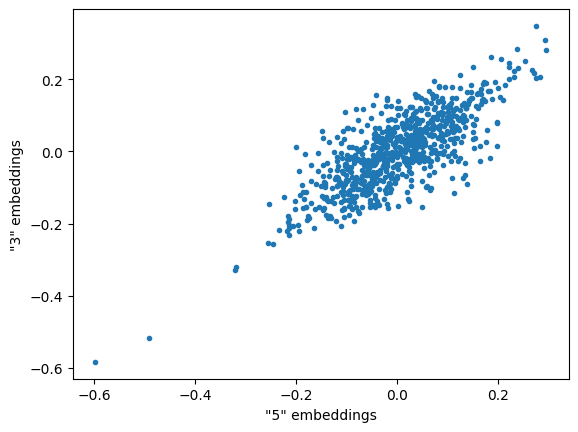

In [64]:
plt.plot(five_em, three_em, '.')
plt.xlabel('"5" embeddings')
plt.ylabel('"3" embeddings')
plt.show()

'5' and '3' are still very similar thats why we still get '5'. Semantically '5' and '3' are digits. So both vector don't change direction of each much.

And for 5*3

In [59]:
three_times_five_em = np.argmax(three_times_five_em @ gpt2_embeddings.T)
three_times_five_em

np.int64(22473)

In [60]:
gpt2_tokenizer.decode(three_times_five_em)

' Weinstein'

By 5 + 3 we actually mean that we add embeddings of '5' to embeddings of '3', we can do that because all embeddings in gpt2 are (,768). When we add just 3, the distance from embeddings of '5' is not that far after adding embeddings of '3' to each dimension, i.e. our closest embedding is still '5'.

Now, when instead we do 5 * 3, we actually do Hadamard (element-wise) multiplication across all dimensions in embeddings of '5' and embeddings of '3'. The output is much further in direction then embeddings of '5' or '3' and we get token ' Weinstein'. That shows us there is no logic behind embeddings in terms of mathematical operations, it's all about semantics.